<a href="https://colab.research.google.com/github/Deekshith0625/Machine_Learning/blob/main/pyStyle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

folders=[
    'pyStyle/dataset/clothing',
    'pyStyle/dataset/outfits',
    'pyStyle/dataset/psychology',
    "pyStyle/dataset/wardrobe",
    "pyStyle/models",
    "pyStyle/notebooks"
]

for folder in folders:
  os.makedirs(folder,exist_ok=True)

In [ ]:
!pip install -q kagglehub

KeyboardInterrupt: 

In [ ]:
import kagglehub
path=kagglehub.dataset_download('vishalbsadanand/deepfashion-1')
print('downloaded to path',path)

Using Colab cache for faster access to the 'deepfashion-1' dataset.
downloaded to path /kaggle/input/deepfashion-1


In [ ]:
print("Dataset location:")
print(path)

print("\nFiles and folders:")
print(os.listdir(path))

Dataset location:
/kaggle/input/deepfashion-1

Files and folders:
['datasets']


In [ ]:
for root, dirs, files in os.walk(path):
    print(root, "→", len(files), "files")

/kaggle/input/deepfashion-1 → 0 files
/kaggle/input/deepfashion-1/datasets → 0 files
/kaggle/input/deepfashion-1/datasets/train_images → 10335 files
/kaggle/input/deepfashion-1/datasets/texture_ann → 0 files
/kaggle/input/deepfashion-1/datasets/texture_ann/val → 3 files
/kaggle/input/deepfashion-1/datasets/texture_ann/test → 4 files
/kaggle/input/deepfashion-1/datasets/texture_ann/train → 3 files
/kaggle/input/deepfashion-1/datasets/segm → 11484 files
/kaggle/input/deepfashion-1/datasets/shape_ann → 3 files
/kaggle/input/deepfashion-1/datasets/densepose → 11484 files
/kaggle/input/deepfashion-1/datasets/test_images → 1149 files


In [ ]:
train_path = os.path.join(path, "datasets", "train_images")
images = os.listdir(train_path)
print("Number of training images:", len(images))
print("\nFirst 20 images:")

for img in images[:20]:
    print(img)

Number of training images: 10335

First 20 images:
WOMEN-Sweaters-id_00005253-06_1_front.png
WOMEN-Blouses_Shirts-id_00004602-01_4_full.png
WOMEN-Blouses_Shirts-id_00007196-04_4_full.png
MEN-Tees_Tanks-id_00004170-05_4_full.png
WOMEN-Tees_Tanks-id_00003917-73_4_full.png
WOMEN-Tees_Tanks-id_00005292-05_7_additional.png
MEN-Jackets_Vests-id_00000094-02_7_additional.png
WOMEN-Dresses-id_00002507-01_7_additional.png
WOMEN-Dresses-id_00001475-03_7_additional.png
WOMEN-Shorts-id_00003578-02_4_full.png
WOMEN-Denim-id_00000194-01_1_front.png
MEN-Tees_Tanks-id_00001808-06_1_front.png
WOMEN-Dresses-id_00004353-04_7_additional.png
WOMEN-Graphic_Tees-id_00006684-01_4_full.png
WOMEN-Tees_Tanks-id_00006679-03_4_full.png
WOMEN-Tees_Tanks-id_00003794-01_7_additional.png
WOMEN-Tees_Tanks-id_00003629-04_4_full.png
MEN-Shirts_Polos-id_00004118-04_7_additional.png
WOMEN-Tees_Tanks-id_00006333-02_4_full.png
WOMEN-Blouses_Shirts-id_00002593-03_4_full.png


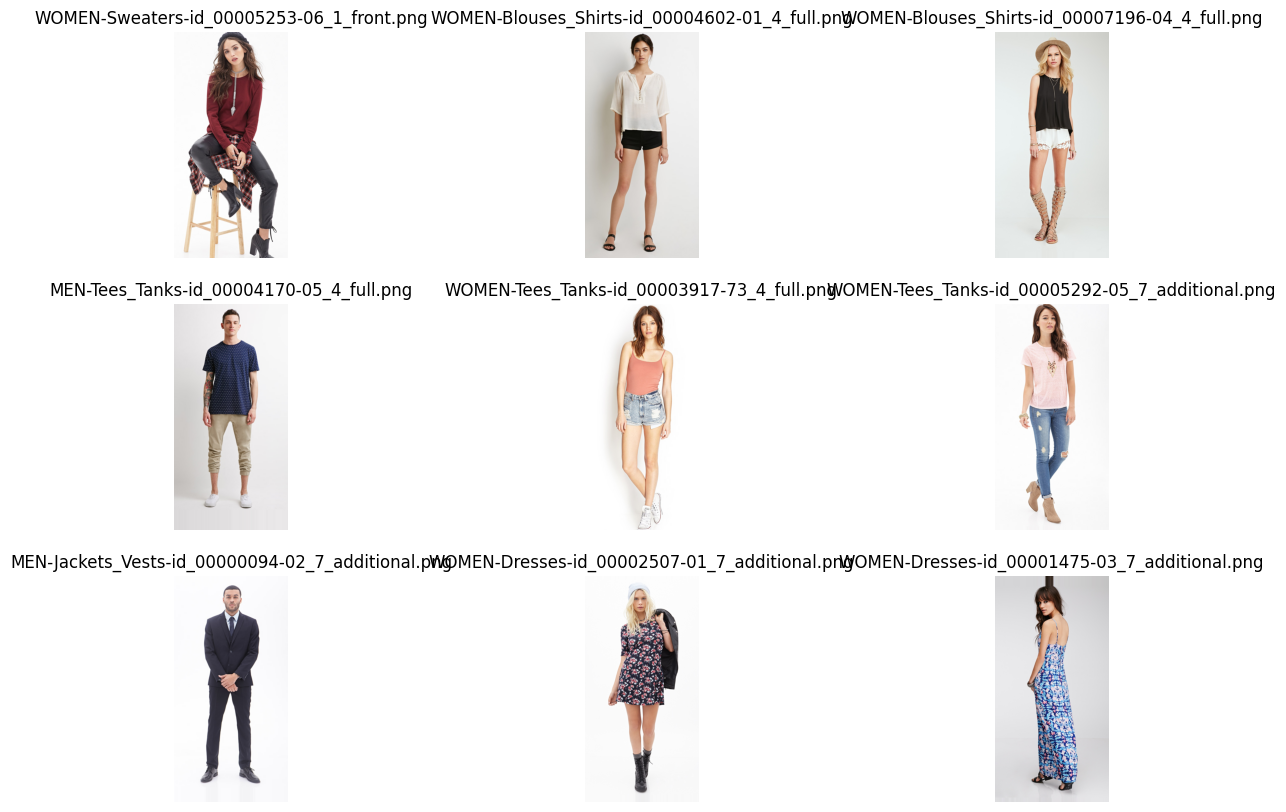

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
plt.figure(figsize=(15, 10))
for i, img_name in enumerate(images[:9]):
    img_path = os.path.join(train_path, img_name)
    img = Image.open(img_path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name)

plt.show()

In [ ]:
from collections import Counter
train_path = os.path.join(path, "datasets", "train_images")

images = os.listdir(train_path)

categories = []

for img in images:
    parts = img.split("-")

    if len(parts) >= 2:
        category = parts[1]
        categories.append(category)

category_counts = Counter(categories)

print("Number of categories:", len(category_counts))
print("\nCategories:\n")

for category, count in category_counts.items():
    print(category, "→", count)

Number of categories: 17

Categories:

Sweaters → 674
Blouses_Shirts → 1377
Tees_Tanks → 2594
Jackets_Vests → 74
Dresses → 1959
Shorts → 612
Denim → 146
Graphic_Tees → 190
Shirts_Polos → 103
Sweatshirts_Hoodies → 265
Pants → 600
Cardigans → 348
Skirts → 340
Rompers_Jumpsuits → 549
Jackets_Coats → 429
Leggings → 67
Suiting → 8


In [ ]:
total = sum(category_counts.values())

print("Total images:", len(images))
print("Images categorized:", total)
print("Images not categorized:", len(images) - total)

Total images: 10335
Images categorized: 10335
Images not categorized: 0


In [ ]:
category_mapping = {
    "Sweaters": "Sweater",
    "Blouses_Shirts": "Shirt",
    "Tees_Tanks": "T-Shirt",
    "Jackets_Vests": "Jacket",
    "Dresses": "Dress",
    "Shorts": "Shorts",
    "Denim": "Jeans",
    "Graphic_Tees": "T-Shirt",
    "Shirts_Polos": "Shirt",
    "Sweatshirts_Hoodies": "Hoodie",
    "Pants": "Trousers",
    "Cardigans": "Cardigan",
    "Skirts": "Skirt",
    "Rompers_Jumpsuits": "Romper",
    "Jackets_Coats": "Jacket",
    "Leggings": "Leggings",
    "Suiting": "Suit"
}

print("Mapping created!")

Mapping created!


In [ ]:
psystyle_categories = sorted(set(category_mapping.values()))

print("PsyStyle categories:")
for i, category in enumerate(psystyle_categories, 1):
    print(i, "→", category)

print("\nTotal:", len(psystyle_categories))

PsyStyle categories:
1 → Cardigan
2 → Dress
3 → Hoodie
4 → Jacket
5 → Jeans
6 → Leggings
7 → Romper
8 → Shirt
9 → Shorts
10 → Skirt
11 → Suit
12 → Sweater
13 → T-Shirt
14 → Trousers

Total: 14


In [ ]:
import pandas as pd

train_path = os.path.join(path, "datasets", "train_images")

train_data = []

for img_name in images:
    parts = img_name.split("-")
    original_category = parts[1]

    psystyle_category = category_mapping[original_category]

    train_data.append({
        "image_name": img_name,
        "image_path": os.path.join(train_path, img_name),
        "original_category": original_category,
        "category": psystyle_category,
        "split": "train"
    })

train_df = pd.DataFrame(train_data)

print(train_df.head())
print("\nTotal images:", len(train_df))

                                       image_name  \
0       WOMEN-Sweaters-id_00005253-06_1_front.png   
1  WOMEN-Blouses_Shirts-id_00004602-01_4_full.png   
2  WOMEN-Blouses_Shirts-id_00007196-04_4_full.png   
3        MEN-Tees_Tanks-id_00004170-05_4_full.png   
4      WOMEN-Tees_Tanks-id_00003917-73_4_full.png   

                                          image_path original_category  \
0  /kaggle/input/deepfashion-1/datasets/train_ima...          Sweaters   
1  /kaggle/input/deepfashion-1/datasets/train_ima...    Blouses_Shirts   
2  /kaggle/input/deepfashion-1/datasets/train_ima...    Blouses_Shirts   
3  /kaggle/input/deepfashion-1/datasets/train_ima...        Tees_Tanks   
4  /kaggle/input/deepfashion-1/datasets/train_ima...        Tees_Tanks   

  category  split  
0  Sweater  train  
1    Shirt  train  
2    Shirt  train  
3  T-Shirt  train  
4  T-Shirt  train  

Total images: 10335


In [ ]:
print(train_df["category"].value_counts())

category
T-Shirt     2784
Dress       1959
Shirt       1480
Sweater      674
Shorts       612
Trousers     600
Romper       549
Jacket       503
Cardigan     348
Skirt        340
Hoodie       265
Jeans        146
Leggings      67
Suit           8
Name: count, dtype: int64


In [ ]:
csv_path = "pyStyle/dataset/clothing/train_metadata.csv"

train_df.to_csv(csv_path, index=False)

print("Saved successfully!")
print(csv_path)

Saved successfully!
pyStyle/dataset/clothing/train_metadata.csv


In [ ]:
test_path = os.path.join(path, "datasets", "test_images")

test_images = os.listdir(test_path)

print("Number of test images:", len(test_images))

Number of test images: 1149


In [ ]:
test_data = []

for img_name in test_images:
    parts = img_name.split("-")
    original_category = parts[1]

    psystyle_category = category_mapping[original_category]

    test_data.append({
        "image_name": img_name,
        "image_path": os.path.join(test_path, img_name),
        "original_category": original_category,
        "category": psystyle_category,
        "split": "test"
    })

test_df = pd.DataFrame(test_data)

print(test_df.head())
print("\nTotal test images:", len(test_df))

                                         image_name  \
0          MEN-Tees_Tanks-id_00001239-08_4_full.png   
1  WOMEN-Tees_Tanks-id_00002553-04_7_additional.png   
2   WOMEN-Cardigans-id_00001328-05_7_additional.png   
3         WOMEN-Cardigans-id_00005164-01_4_full.png   
4           WOMEN-Dresses-id_00003892-01_4_full.png   

                                          image_path original_category  \
0  /kaggle/input/deepfashion-1/datasets/test_imag...        Tees_Tanks   
1  /kaggle/input/deepfashion-1/datasets/test_imag...        Tees_Tanks   
2  /kaggle/input/deepfashion-1/datasets/test_imag...         Cardigans   
3  /kaggle/input/deepfashion-1/datasets/test_imag...         Cardigans   
4  /kaggle/input/deepfashion-1/datasets/test_imag...           Dresses   

   category split  
0   T-Shirt  test  
1   T-Shirt  test  
2  Cardigan  test  
3  Cardigan  test  
4     Dress  test  

Total test images: 1149


In [ ]:
print(test_df["category"].value_counts())

category
T-Shirt     317
Dress       212
Shirt       160
Sweater      77
Shorts       76
Romper       63
Trousers     58
Jacket       51
Skirt        44
Cardigan     33
Hoodie       32
Jeans        15
Leggings     11
Name: count, dtype: int64


In [ ]:
test_csv_path = "pyStyle/dataset/clothing/test_metadata.csv"

test_df.to_csv(test_csv_path, index=False)

print("Saved successfully!")
print(test_csv_path)

Saved successfully!
pyStyle/dataset/clothing/test_metadata.csv


In [ ]:
print("Training data:", len(train_df))
print("Testing data:", len(test_df))

print("\nFiles:")
print(os.listdir("pyStyle/dataset/clothing"))

Training data: 10335
Testing data: 1149

Files:
['train_metadata.csv', 'test_metadata.csv']


In [ ]:
print("Training data:", len(train_df))
print("Testing data:", len(test_df))
print(test_df["category"].value_counts())

Training data: 10335
Testing data: 1149
category
T-Shirt     317
Dress       212
Shirt       160
Sweater      77
Shorts       76
Romper       63
Trousers     58
Jacket       51
Skirt        44
Cardigan     33
Hoodie       32
Jeans        15
Leggings     11
Name: count, dtype: int64


In [ ]:
import tensorflow as tf
import keras

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
Keras version: 3.13.2
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (224, 224)
Batch size: 32


In [ ]:
train_df = pd.read_csv(
    "pyStyle/dataset/clothing/train_metadata.csv"
)

test_df = pd.read_csv(
    "pyStyle/dataset/clothing/test_metadata.csv"
)

print("Training images:", len(train_df))
print("Testing images:", len(test_df))

print("\nTraining columns:")
print(train_df.columns)

Training images: 10335
Testing images: 1149

Training columns:
Index(['image_name', 'image_path', 'original_category', 'category', 'split'], dtype='object')


In [ ]:
train_df["label"] = train_df["category"].map(category_to_index)
test_df["label"] = test_df["category"].map(category_to_index)

print(train_df.head())

                                         image_name  \
0           WOMEN-Dresses-id_00000731-10_4_full.png   
1            WOMEN-Shorts-id_00000144-01_4_full.png   
2     WOMEN-Dresses-id_00005927-02_7_additional.png   
3  WOMEN-Tees_Tanks-id_00004702-02_7_additional.png   
4  WOMEN-Tees_Tanks-id_00006410-03_7_additional.png   

                                          image_path original_category  \
0  /root/.cache/kagglehub/datasets/vishalbsadanan...           Dresses   
1  /root/.cache/kagglehub/datasets/vishalbsadanan...            Shorts   
2  /root/.cache/kagglehub/datasets/vishalbsadanan...           Dresses   
3  /root/.cache/kagglehub/datasets/vishalbsadanan...        Tees_Tanks   
4  /root/.cache/kagglehub/datasets/vishalbsadanan...        Tees_Tanks   

  category  split  label  
0    Dress  train      1  
1   Shorts  train      8  
2    Dress  train      1  
3  T-Shirt  train     12  
4  T-Shirt  train     12  


In [ ]:
def load_image(image_path, label):
    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(image, IMG_SIZE)

    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_df["image_path"].values,
        train_df["label"].values
    )
)

train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.shuffle(1000)

train_dataset = train_dataset.batch(BATCH_SIZE)

train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)

print("Training dataset created!")

Training dataset created!


In [ ]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        test_df["image_path"].values,
        test_df["label"].values
    )
)

test_dataset = test_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.batch(BATCH_SIZE)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)

print("Test dataset created!")

Test dataset created!


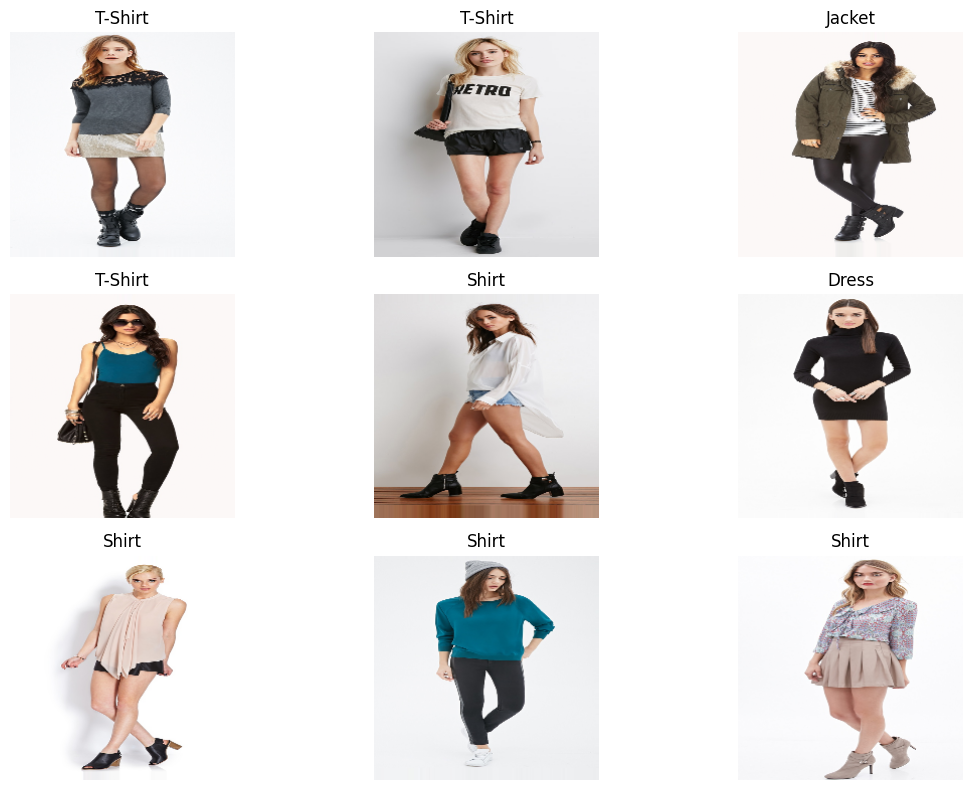

In [ ]:
class_names = categories

plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i])

        plt.title(class_names[labels[i].numpy()])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
  IMG_SIZE = (224, 224)

def load_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(image, IMG_SIZE)

    image = tf.cast(image, tf.float32)

    image = preprocess_input(image)

    return image, label

In [ ]:
print(train_df.columns)

Index(['image_name', 'image_path', 'original_category', 'category', 'split'], dtype='object')


In [ ]:
categories = sorted(train_df["category"].unique())

category_to_index = {
    category: index
    for index, category in enumerate(categories)
}

index_to_category = {
    index: category
    for category, index in category_to_index.items()
}

print("Categories:")

for index, category in index_to_category.items():
    print(index, "→", category)

print("\nNumber of classes:", len(categories))

Categories:
0 → Cardigan
1 → Dress
2 → Hoodie
3 → Jacket
4 → Jeans
5 → Leggings
6 → Romper
7 → Shirt
8 → Shorts
9 → Skirt
10 → Suit
11 → Sweater
12 → T-Shirt
13 → Trousers

Number of classes: 14


In [ ]:
train_df["label"] = train_df["category"].map(category_to_index)
test_df["label"] = test_df["category"].map(category_to_index)

print(train_df.head())

                                         image_name  \
0           WOMEN-Dresses-id_00000731-10_4_full.png   
1            WOMEN-Shorts-id_00000144-01_4_full.png   
2     WOMEN-Dresses-id_00005927-02_7_additional.png   
3  WOMEN-Tees_Tanks-id_00004702-02_7_additional.png   
4  WOMEN-Tees_Tanks-id_00006410-03_7_additional.png   

                                          image_path original_category  \
0  /root/.cache/kagglehub/datasets/vishalbsadanan...           Dresses   
1  /root/.cache/kagglehub/datasets/vishalbsadanan...            Shorts   
2  /root/.cache/kagglehub/datasets/vishalbsadanan...           Dresses   
3  /root/.cache/kagglehub/datasets/vishalbsadanan...        Tees_Tanks   
4  /root/.cache/kagglehub/datasets/vishalbsadanan...        Tees_Tanks   

  category  split  label  
0    Dress  train      1  
1   Shorts  train      8  
2    Dress  train      1  
3  T-Shirt  train     12  
4  T-Shirt  train     12  


In [ ]:
train_df.to_csv(
    "pyStyle/dataset/clothing/train_metadata.csv",
    index=False
)

test_df.to_csv(
    "pyStyle/dataset/clothing/test_metadata.csv",
    index=False
)

print("Both CSV files updated successfully!")

Both CSV files updated successfully!


In [ ]:
print("Training columns:")
print(train_df.columns)

print("\nTesting columns:")
print(test_df.columns)

Training columns:
Index(['image_name', 'image_path', 'original_category', 'category', 'split',
       'label'],
      dtype='object')

Testing columns:
Index(['image_name', 'image_path', 'original_category', 'category', 'split',
       'label'],
      dtype='object')


In [ ]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df["label"],
    random_state=42
)

print("Training images:", len(train_data))
print("Validation images:", len(val_data))

Training images: 8268
Validation images: 2067


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(image, IMG_SIZE)

    image = tf.cast(image, tf.float32)

    image = preprocess_input(image)

    return image, label

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_data["image_path"].values,
        train_data["label"].values
    )
)

train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.shuffle(1000)

train_dataset = train_dataset.batch(BATCH_SIZE)

train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)

print("Training dataset ready!")

Training dataset ready!


In [ ]:
val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        val_data["image_path"].values,
        val_data["label"].values
    )
)

val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.batch(BATCH_SIZE)

val_dataset = val_dataset.prefetch(
    tf.data.AUTOTUNE
)

print("Validation dataset ready!")

Validation dataset ready!


In [ ]:
for images, labels in train_dataset.take(1):

    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)
    print("Labels:", labels[:10].numpy())

Image shape: (32, 224, 224, 3)
Label shape: (32,)
Labels: [ 1  6 12 12  7  4 12  7 12  6]


In [ ]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("ResNet50 loaded successfully!")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 loaded successfully!


In [ ]:
base_model.trainable = False

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(len(categories), activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,115,854 (91.99 MB)

 Trainable params: 528,142 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5
)

Epoch 1/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 132s 419ms/step - accuracy: 0.4144 - loss: 1.7580 - val_accuracy: 0.5080 - val_loss: 1.4457
Epoch 2/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 107s 377ms/step - accuracy: 0.4990 - loss: 1.4451 - val_accuracy: 0.5225 - val_loss: 1.3830
Epoch 3/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 98s 342ms/step - accuracy: 0.5284 - loss: 1.3423 - val_accuracy: 0.5535 - val_loss: 1.3212
Epoch 4/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 145s 359ms/step - accuracy: 0.5604 - loss: 1.2518 - val_accuracy: 0.5568 - val_loss: 1.2878
Epoch 5/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 107s 379ms/step - accuracy: 0.5796 - loss: 1.1975 - val_accuracy: 0.5612 - val_loss: 1.2905
